# 🎤 Continuous Voice Tracker
This notebook isolates the Voice Detection pipeline (Structural Cross-Masking engine). It effectively distinguishes human vocals from dense electronic music.

In [42]:
import librosa
import numpy as np
import time
import warnings
warnings.filterwarnings('ignore')
from IPython.display import display, clear_output

def default_infos():
    return {
        "useMicrophone": True,
        "HARDWARE_MODE": "simulation",
    }


### 1. Song Loading

In [43]:
song_files = [
    'mp3_files/Palladium.mp3',
    'mp3_files/Pumped Up Kicks.mp3',
    'mp3_files\\Sugar (feat. Francesco Yates).mp3',
    'mp3_files\Roxanne - Remastered 2003.mp3'
]

print(f"Loading {len(song_files)} songs sequentially...")

y_list = []
for i, f in enumerate(song_files):
    y, sr = librosa.load(f.replace('\\', '/'), sr=44100)
    y_list.append(y)

y_full = np.concatenate(y_list) if y_list else np.array([])
print(f"✅ Audio loading complete! Total frames: {len(y_full)}")



Loading 4 songs sequentially...
✅ Audio loading complete! Total frames: 45160281


### 2. High Resolution FFT Microphones

In [44]:
class Robust_Simulated_Microphone:
    def __init__(self, y_full_array, bandValues, infos):
        self.bandValues = bandValues
        self.nb_of_fft_band = len(self.bandValues)
        
        self.sample_rate = 44100
        self.buffer_size = 1024 
        self.audio_data = np.zeros(self.buffer_size)
        
        self.full_audio = y_full_array
        self.total_samples = len(self.full_audio)
        self.current_pos = 0
        
        fft_size = self.buffer_size // 2 + 1
        self.weight_matrix = np.zeros((self.nb_of_fft_band, fft_size))
        
        def hz_to_mel(f): return 2595 * np.log10(1 + f / 700.0)
        def mel_to_hz(m): return 700 * (10**(m / 2595.0) - 1)
        
        lower_mel = hz_to_mel(20)
        upper_mel = hz_to_mel(20000)
        mel_points = np.linspace(lower_mel, upper_mel, self.nb_of_fft_band + 2)
        hz_points = mel_to_hz(mel_points)
        bin_points = np.floor((self.buffer_size + 1) * hz_points / self.sample_rate).astype(int)
        
        for i in range(self.nb_of_fft_band):
            start = min(bin_points[i], fft_size - 1)
            mid = min(bin_points[i + 1], fft_size - 1)
            end = min(bin_points[i + 2], fft_size - 1)
            if mid > start:
                self.weight_matrix[i, start:mid] = np.linspace(0, 1, mid - start, endpoint=False)
            if end > mid:
                self.weight_matrix[i, mid:end] = np.linspace(1, 0, end - mid, endpoint=False)
            band_sum = np.sum(self.weight_matrix[i, :])
            if band_sum > 0:
                self.weight_matrix[i, :] /= band_sum
                
        self.raw_fft_history = None
        self.spectral_complexity = 0.0
        self.bass_flux = 0.0
        self.vocal_flux = 0.0
        self.treble_flux = 0.0
        self.high_res_flux = 0.0
        self.vocal_energy = 0.0
        self.bass_energy = 0.0
        self.treble_energy = 0.0
        self.current_pitch = 0.0

    def pop_chunk(self, chunk_size=1024):
        if self.current_pos + chunk_size > self.total_samples:
            return False 
        
        incoming = self.full_audio[self.current_pos : self.current_pos + chunk_size]
        self.current_pos += chunk_size
        self.audio_data = np.roll(self.audio_data, -chunk_size)
        self.audio_data[-chunk_size:] = incoming
        return True

    def calculate_fft(self):
        windowed_data = self.audio_data * np.hanning(self.buffer_size)
        fft_result = np.abs(np.fft.rfft(windowed_data))
        
        # Harmonic Product Spectrum (HPS) for heuristic SVD pitch extraction
        hps = np.copy(fft_result)
        for d in [2, 3, 4]:
            decimated = fft_result[::d]
            hps[:len(decimated)] *= decimated
        
        # Mask out bins outside typical human fundamental pitch range (approx 80Hz - 1000Hz)
        hps[:2] = 0
        hps[24:] = 0
        peak_bin = np.argmax(hps)
        self.current_pitch = peak_bin * (self.sample_rate / self.buffer_size)
        
        scale = 150.0 / (self.buffer_size / 1024.0)
        mel_bands = np.dot(self.weight_matrix, fft_result) * scale
        for i in range(self.nb_of_fft_band):
            self.bandValues[i] = int(mel_bands[i])

        if self.raw_fft_history is not None:
            freq_diff = np.maximum(0, fft_result - self.raw_fft_history)
            self.bass_flux = np.sum(freq_diff[1:7])
            self.vocal_flux = np.sum(freq_diff[7:70])
            self.treble_flux = np.sum(freq_diff[70:300])
            self.high_res_flux = self.treble_flux
            vocal_spec = fft_result[7:70]
            self.vocal_energy = np.sum(vocal_spec)
            self.bass_energy = np.sum(fft_result[1:7])
            self.treble_energy = np.sum(fft_result[70:-1])
            vmax = np.max(vocal_spec)
            vmean = np.mean(vocal_spec)
            self.spectral_complexity = vmean / (vmax + 0.001)
        self.raw_fft_history = fft_result


### 3. Voice Tracking Engine (Structural Cross-Masking)

In [45]:
infos = default_infos()

SIMULATED_FPS = 60.0
TIME_PER_FRAME = 1.0 / SIMULATED_FPS
CHUNK_SIZE_FOR_60FPS = int(44100 / SIMULATED_FPS)

mic = Robust_Simulated_Microphone(y_full, np.zeros(8, dtype=int), infos)

history_time = []
history_vocals_present = []
history_vocal_score = []
history_complexity = []
history_variance = []
acapella_events = []
last_acapella_frame = -9999
ACAPELLA_COOLDOWN_FRAMES = int(5.0 * SIMULATED_FPS)

audio_time = 0.0
playhead_time = 0.0
frame = 0

smooth_suppression = 50.0
smooth_vocal = 0.0
ema_complexity = 0.0
COMPLEXITY_ALPHA = 0.1
asserved_bass_energy = 0.0
asserved_treble_energy = 0.0
asserved_bass_flux = 0.0
asserved_treble_flux = 0.0
EMA_ALPHA = 0.0066  # Approximates a 5-second moving average at 60 FPS

acapella_state = False
hangover_frames = 0
DILATION_FRAMES = int(0.5 * SIMULATED_FPS)

# Heuristic SVD Tracking Variables
pitch_history = np.zeros(64) # ~1 second history at 60fps
current_vibrato_energy = 0.0

print("🚀 Starting Voice Tracking Simulation with Heuristic SVD...")

while mic.pop_chunk(CHUNK_SIZE_FOR_60FPS):
    mic.calculate_fft()
    
    # Store pitch in circular buffer
    pitch_history = np.roll(pitch_history, -1)
    pitch_history[-1] = mic.current_pitch
    
    # Calculate Vibrato every frame (FFT of pitch history)
    # The buffer covers 60 frames (~1 sec). We look at frequency bins correspoinding to 4-8Hz.
    # With 64 samples at 60 FPS, the resolution is 60/64 = 0.9375 Hz per bin.
    # Bin 4 = ~3.75 Hz, Bin 8 = ~7.5 Hz 
    pitch_fft = np.abs(np.fft.rfft(pitch_history))
    vibrato_energy = np.sum(pitch_fft[4:9]) # 4 to 8 Hz bins
    
    # Optional smoothing
    current_vibrato_energy = current_vibrato_energy * 0.9 + vibrato_energy * 0.1
    
    bass_energy = mic.bass_energy
    treble_energy = mic.treble_energy
    
    # Exponential moving averages for baseline audio
    asserved_bass_energy = asserved_bass_energy * (1 - EMA_ALPHA) + bass_energy * EMA_ALPHA
    asserved_treble_energy = asserved_treble_energy * (1 - EMA_ALPHA) + treble_energy * EMA_ALPHA
    asserved_bass_flux = asserved_bass_flux * (1 - EMA_ALPHA) + mic.bass_flux * EMA_ALPHA
    asserved_treble_flux = asserved_treble_flux * (1 - EMA_ALPHA) + mic.treble_flux * EMA_ALPHA

    vocal_score = current_vibrato_energy / 100.0  # normalize vibrato for plotting 
    
    # Heuristic Detection logic
    score_high_threshold = 2.0  # tunable threshold
    score_low_threshold = 1.0
    
    if not acapella_state:
        # Constraint on bass flux to prevent instrumental drop triggers
        if vocal_score > score_high_threshold and mic.bass_flux < (asserved_bass_flux * 0.8 + 10.0):
            acapella_state = True
            hangover_frames = DILATION_FRAMES
    else:
        if vocal_score > score_low_threshold:
            hangover_frames = DILATION_FRAMES
        else:
            hangover_frames -= 1
            if hangover_frames <= 0:
                acapella_state = False

    vocals_present = acapella_state
    
    # Event cooldown system
    if mic.bass_flux < 5.0 and acapella_state:
        if (frame - last_acapella_frame) > ACAPELLA_COOLDOWN_FRAMES:
            acapella_events.append(playhead_time)
            last_acapella_frame = frame

    history_time.append(playhead_time)
    ema_complexity = ema_complexity * (1 - COMPLEXITY_ALPHA) + mic.spectral_complexity * COMPLEXITY_ALPHA
    
    if len(history_complexity) > 0:
        history_complexity.append(ema_complexity*0.5 + history_complexity[-1]*0.95)
    else:
        history_complexity.append(ema_complexity)
    
    diff = ema_complexity - history_complexity[-1]
    if len(history_variance) > 0:
        history_variance.append(0.9 * history_variance[-1] + 0.1 * diff * diff)
    else:
        history_variance.append(diff*diff)
        
    history_vocals_present.append(vocals_present)
    history_vocal_score.append(vocal_score)
    
    playhead_time += TIME_PER_FRAME
    audio_time += TIME_PER_FRAME
    frame += 1
    
    if frame % 1800 == 0:
        print(f"Processed audio time {audio_time:.1f}s...")

print(f"✅ Simulation Complete! Detected {len(acapella_events)} distinct acapella events.")


🚀 Starting Voice Tracking Simulation with Heuristic SVD...
Processed audio time 30.0s...
Processed audio time 60.0s...
Processed audio time 90.0s...
Processed audio time 120.0s...
Processed audio time 150.0s...
Processed audio time 180.0s...
Processed audio time 210.0s...
Processed audio time 240.0s...
Processed audio time 270.0s...
Processed audio time 300.0s...
Processed audio time 330.0s...
Processed audio time 360.0s...
Processed audio time 390.0s...
Processed audio time 420.0s...
Processed audio time 450.0s...
Processed audio time 480.0s...
Processed audio time 510.0s...
Processed audio time 540.0s...
Processed audio time 570.0s...
Processed audio time 600.0s...
Processed audio time 630.0s...
Processed audio time 660.0s...
Processed audio time 690.0s...
Processed audio time 720.0s...
Processed audio time 750.0s...
Processed audio time 780.0s...
Processed audio time 810.0s...
Processed audio time 840.0s...
Processed audio time 870.0s...
Processed audio time 900.0s...
Processed audi

### 4. Diagnostic Visualization

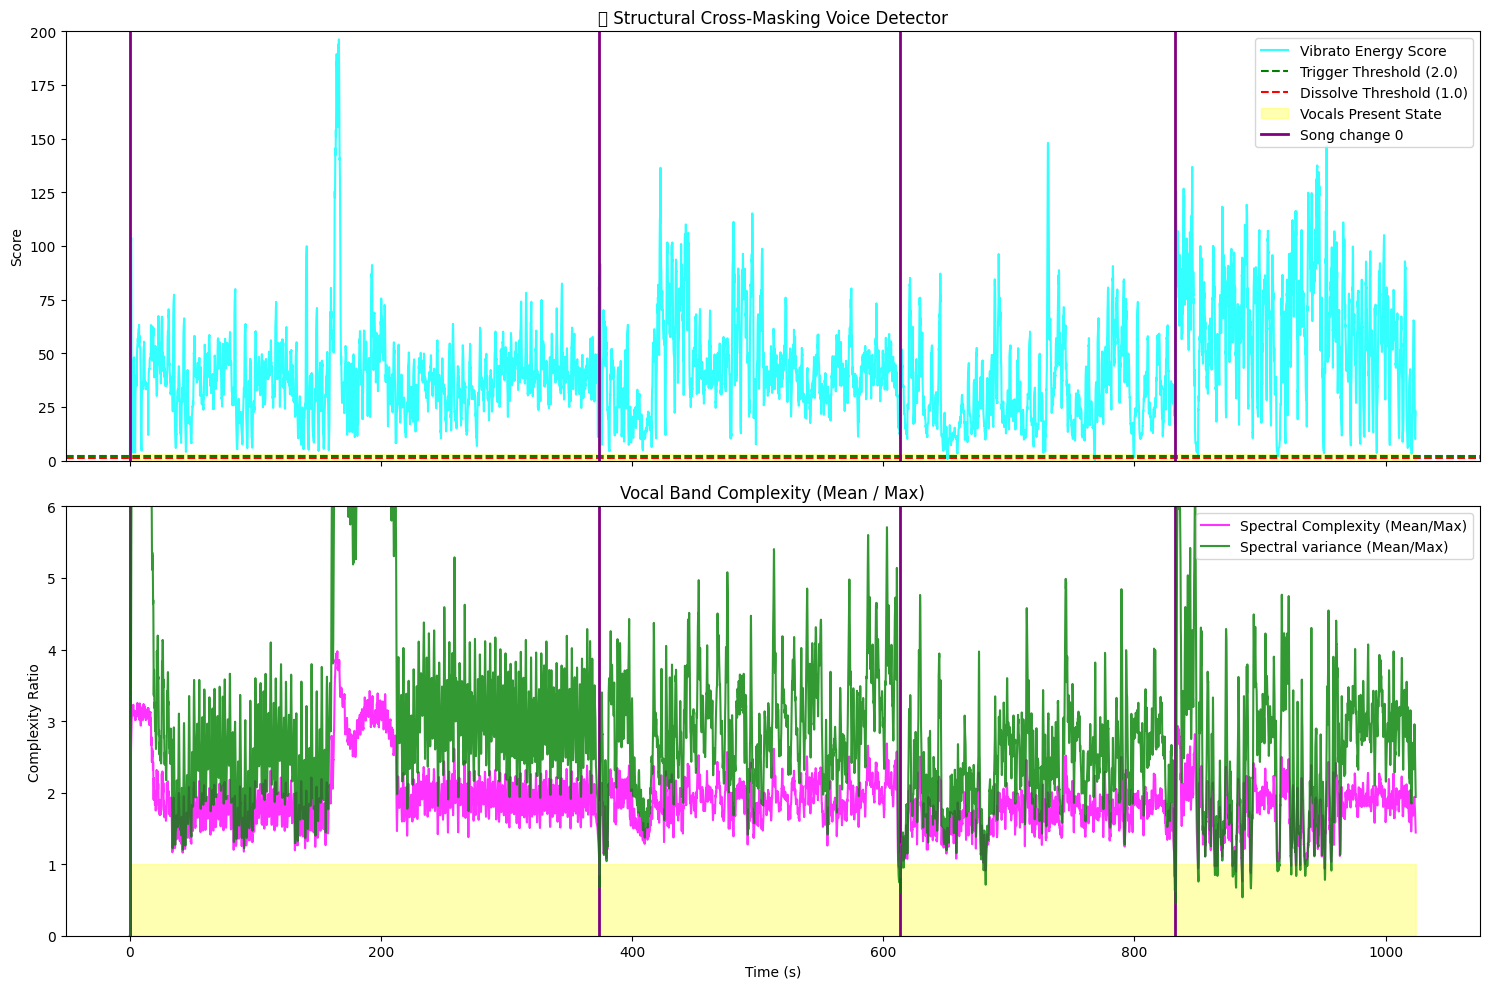

In [46]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

# Top Plot: Vocal Score
ax1.plot(history_time, history_vocal_score, label="Vibrato Energy Score", color="cyan", alpha=0.8)
ax1.axhline(2.0, color="green", linestyle="--", label="Trigger Threshold (2.0)")
ax1.axhline(1.0, color="red", linestyle="--", label="Dissolve Threshold (1.0)")
ax1.fill_between(history_time, 0, 3, where=history_vocals_present, color="yellow", alpha=0.3, label="Vocals Present State")

y=0
for k in range(len(y_list)):
    y_k = y_list[k]
    ax1.axvline(y/sr, color="purple", linestyle="-", linewidth=2, label=f"Song change {k}" if k==0 else "")
    ax2.axvline(y/sr, color="purple", linestyle="-", linewidth=2)
    y+= len(y_k)

ax1.set_ylim(0, 200)
ax1.set_title("🎤 Structural Cross-Masking Voice Detector")
ax1.set_ylabel("Score")
ax1.legend(loc="upper right")

# Bottom Plot: Spectral Complexity
ax2.plot(history_time, history_complexity, label="Spectral Complexity (Mean/Max)", color="magenta", alpha=0.8)
ax2.plot(history_time, history_variance, label="Spectral variance (Mean/Max)", color="green", alpha=0.8)

ax2.fill_between(history_time, 0, 1, where=history_vocals_present, color="yellow", alpha=0.3)
ax2.set_ylim(0, 6)
ax2.set_title("Vocal Band Complexity (Mean / Max)")
ax2.set_xlabel("Time (s)")
ax2.set_ylabel("Complexity Ratio")
ax2.legend(loc="upper right")

plt.tight_layout()
plt.show()
